# Goal of this notebook
Here we aim to gain superficial knowledge about node-level and graph-level features in different datasets.
For "dataset" we mean the ensamble of uniprot's node features and stringdb's connectivity.
### Used datasets
Main experiments:
- Alzheimer's Disease (AD)
- Parkinson's Disease (PD) 

Testing and validation:
- Amyotrophic Lateral Sclerosis (ALS)
- Huntington's Disease (HD)
- Frontotemporal Dementia (FTD)
- Multiple System Atrophy (MSA)

Diabetes (Type 1 and Type 2) are discarded fro experiments because they are too overlapping.
### Extracted features
Node-level feature:
- degree statistics
- centrality measures
- GO statistics
Graph level features:
- mean connectivity
- number of nodes connected components
- number of nodes and egdes per class


In [2]:
import pandas as pd
from pathlib import Path

source_path = Path('./sources')
test_source_path = source_path / Path('test_db')
diabetes_source_path = source_path / Path('diabetes')

AD_PATH = source_path / Path('UniProtKB-Alzheimer.tsv')
PD_PATH = source_path / Path('UniProtKB-Parkinson.tsv')
D1_PATH = test_source_path / Path('UniProtKB-MS.tsv')
D2_PATH = test_source_path / Path('UniProtKB-SLE.tsv')

ad_csv = pd.read_csv(AD_PATH, sep='\t')
pd_csv = pd.read_csv(PD_PATH, sep='\t')
t1_csv = pd.read_csv(D1_PATH, sep='\t')
t2_csv = pd.read_csv(D2_PATH, sep='\t')

entry_set_ad = set(ad_csv['Entry'].to_list())
entry_set_pd = set(pd_csv['Entry'].to_list())
entry_set_t1 = set(t1_csv['Entry'].to_list())
entry_set_t2 = set(t2_csv['Entry'].to_list())

print('C1 len: ', len(entry_set_t1))
print('C2 len: ', len(entry_set_t2))

common_test = set.intersection(entry_set_t1, entry_set_t2)
print('Common test_db proteins', len(common_test), "\n", common_test)

entry_set_neuro = set.union(entry_set_pd, entry_set_ad)
entry_set_diabetes = set.union(entry_set_t1, entry_set_t2)

print("neurodegenerative proteins: ", len(entry_set_neuro))
print("diabetes proteins: ", len(entry_set_diabetes))

common = set.intersection(entry_set_diabetes, entry_set_neuro)
print("common proteins: ", len(common), "\n", common)

print("common of commons: ", len(set.intersection(common_test, common)), "\n", set.intersection(common_test, common))

ad_csv.head()

C1 len:  89
C2 len:  91
Common test_db proteins 6 
 {'Q9HAT2', 'Q8IZA0', 'P01911', 'P06702', 'P05109', 'Q13568'}
neurodegenerative proteins:  390
diabetes proteins:  174
common proteins:  11 
 {'Q99497', 'P10636', 'P49768', 'P06702', 'Q00535', 'P09429', 'P68036', 'P20700', 'P55290', 'Q13501', 'P48023'}
common of commons:  1 
 {'P06702'}


,Entry,Entry Name,Protein names,Gene Names,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (molecular function),Gene Ontology IDs,Gene Ontology (GO),STRING
0,A1KXE4,F168B_HUMAN,Myelin-associated neurite-outgrowth inhibitor ...,FAM168B KIAA0280L MANI,NaN,axon [GO:0030424]; extracellular exosome [GO:0...,NaN,GO:0005886; GO:0030424; GO:0048471; GO:0070062,axon [GO:0030424]; extracellular exosome [GO:0...,9606.ENSP00000374565
1,A4D1B5,GSAP_HUMAN,Gamma-secretase-activating protein (GSAP) (Pro...,GSAP PION,positive regulation of amyloid-beta formation ...,trans-Golgi network [GO:0005802],amyloid-beta binding [GO:0001540],GO:0001540; GO:0005802; GO:0030162; GO:1902004,trans-Golgi network [GO:0005802]; amyloid-beta...,9606.ENSP00000257626
2,O00189,AP4M1_HUMAN,AP-4 complex subunit mu-1 (AP-4 adaptor comple...,AP4M1 MUARP2,autophagosome assembly [GO:0000045]; Golgi to ...,AP-4 adaptor complex [GO:0030124]; clathrin ad...,protein domain specific binding [GO:0019904]; ...,GO:0000045; GO:0005769; GO:0005802; GO:0005829...,AP-4 adaptor complex [GO:0030124]; clathrin ad...,9606.ENSP00000403663
3,O00213,APBB1_HUMAN,Amyloid beta precursor protein binding family ...,APBB1 FE65 RIR,apoptotic process [GO:0006915]; axonogenesis [...,cytoplasm [GO:0005737]; endoplasmic reticulum ...,amyloid-beta binding [GO:0001540]; chromatin b...,GO:0000122; GO:0001540; GO:0003682; GO:0003713...,cytoplasm [GO:0005737]; endoplasmic reticulum ...,9606.ENSP00000477213
4,O00429,DNM1L_HUMAN,Dynamin-1-like protein (EC 3.6.5.5) (Dnm1p/Vps...,DNM1L DLP1 DRP1,calcium ion transport [GO:0006816]; endocytosi...,brush border [GO:0005903]; clathrin-coated pit...,GTP binding [GO:0005525]; GTP-dependent protei...,GO:0000266; GO:0003924; GO:0005096; GO:0005525...,brush border [GO:0005903]; clathrin-coated pit...,9606.ENSP00000449089


Notes from the analysis below:
- Every couple of ALS, HD and MSA are suitable because they share few proteins
- Those share few proteins with alzheimer and parkinson's too.

TODO: graph analyse those

In [3]:
from data_visualization.graph_analyzer import GraphAnalyzer
from data_pipeline.dataset import NeuroDegAnc2VecDataset
import torch_geometric.transforms as T
from data_pipeline import *

import pandas as pd
from pathlib import Path

import itertools

project_root = Path('.')
source_path = project_root / 'sources'
test_source_path = source_path / 'test_db'
diabetes_source_path = source_path / 'diabetes'


ad_path  = source_path / 'UniProtKB-Alzheimer.tsv'
pd_path  = source_path / 'UniProtKB-Parkinson.tsv'
als_path = test_source_path / 'UniProtKB-ALS.tsv'   # Amyotrophic Lateral Sclerosis
hd_path  = test_source_path / 'UniProtKB-HD.tsv'    # Huntington's Disease
ftd_path = test_source_path / 'UniProtKB-FTD.tsv'   # Frontotemporal Dementia
msa_path = test_source_path / 'UniProtKB-MSA.tsv'   # Multiple System Atrophy

to_compare_ds = [ad_path, pd_path, als_path, hd_path, ftd_path, msa_path]

def short_name_extract(s):
    s = str(s)
    return s.split('-')[-1].split('.')[0]

for i in range(len(to_compare_ds)):
    d1 = to_compare_ds[i]
    ds1 = pd.read_csv(d1, sep='\t')
    string_id_1 = set(ds1['STRING'].to_list())
    for j in range(i+1, len(to_compare_ds)):
        d2 = to_compare_ds[j]
        ds2 = pd.read_csv(d2, sep='\t')
        string_id_2 = set(ds2['STRING'].to_list())

        common = set.intersection(string_id_1, string_id_2)
        print(f'Common prots: {short_name_extract(d1)}({len(string_id_1)}) {short_name_extract(d2)}({len(string_id_2)}) | {len(common)} | {common}')
        





/home/emanuele/Documents/Tesi/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Common prots: Alzheimer(231) Parkinson(173) | 20 | {'9606.ENSP00000419782', '9606.ENSP00000284440', '9606.ENSP00000298910', nan, '9606.ENSP00000309457', '9606.ENSP00000354687', '9606.ENSP00000301015', '9606.ENSP00000264710', '9606.ENSP00000311816', '9606.ENSP00000366047', '9606.ENSP00000328088', '9606.ENSP00000309124', '9606.ENSP00000345023', '9606.ENSP00000340820', '9606.ENSP00000366506', '9606.ENSP00000377296', '9606.ENSP00000500990', '9606.ENSP00000374455', '9606.ENSP00000284981', '9606.ENSP00000358513'}
Common prots: Alzheimer(231) ALS(101) | 1 | {nan}
Common prots: Alzheimer(231) HD(62) | 0 | set()
Common prots: Alzheimer(231) FTD(41) | 0 | set()
Common prots: Alzheimer(231) MSA(109) | 1 | {nan}
Common prots: Parkinson(173) ALS(101) | 1 | {nan}
Common prots: Parkinson(173) HD(62) | 0 | set()
Common prots: Parkinson(173) FTD(41) | 0 | set()
Common prots: Parkinson(173) MSA(109) | 1 | {nan}
Common prots: ALS(101) HD(62) | 4 | {'9606.ENSP00000264867;', '9606.ENSP00000374455;', '9606.

In [4]:
def get_unique_go_terms(df, column_name='Gene Ontology IDs'):
    """Estrae l'insieme dei termini GO unici da una colonna di stringhe separate da ';'."""
    # 1. Splitta ed elimina gli spazi usando la regex `;\s*`
    splitted_series = df[column_name].fillna("").str.split(r';\s*')
    
    # 2. Srotola la lista di liste (flattening) in un unico set, escludendo stringhe vuote
    unique_terms = set(
        term for sublist in splitted_series 
        for term in sublist if term.strip() != ""
    )
    return unique_terms

# --- CALCOLO DELL'INDICE DI JACCARD ---
print('===== Pairwise Jaccard comparison =====')
to_compare_ds = [ad_path, pd_path, als_path, hd_path, ftd_path, msa_path]
for i in range(len(to_compare_ds)):
    d1 = to_compare_ds[i]
    ds1 = pd.read_csv(d1, sep='\t')
    go_set_1 = get_unique_go_terms(ds1)
    for j in range(i+1, len(to_compare_ds)):
        d2 = to_compare_ds[j]
        ds2 = pd.read_csv(d2, sep='\t')
        go_set_2 = get_unique_go_terms(ds2)

        # Calcolo di Intersezione e Unione
        intersezione = go_set_1.intersection(go_set_2)
        unione = go_set_1.union(go_set_2)

        # Indice di Jaccard
        jaccard_index = len(intersezione) / len(unione) if len(unione) > 0 else 0
        print(f"J({short_name_extract(d1)}, {short_name_extract(d2)}) = {jaccard_index:.3f}")

print("\n")
print("===== Train-Test Jaccard Comparison =====")

def merge_go_set(df_path1, df_path2, column_name='Gene Ontology IDs') -> set:
    go1 = get_unique_go_terms(pd.read_csv(df_path1, sep='\t'), column_name)
    go2 = get_unique_go_terms(pd.read_csv(df_path2, sep='\t'), column_name)

    return set.union(go1, go2)

ad_pd = merge_go_set(ad_path, pd_path)
als_hd = merge_go_set(als_path, hd_path)
als_msa = merge_go_set(als_path, msa_path)
hd_msa = merge_go_set(hd_path, msa_path)

for k,v in {'ALS-HD': als_hd, 'ALS-MSA': als_msa, 'HD-MSA': hd_msa}.items():
    intersection = set.intersection(ad_pd, v)
    union = set.union(ad_pd, v)
    jaccard_index = len(intersection) / len(union) if len(union) > 0 else 0
    print(f"J(AD-PD, {k}) = {jaccard_index:.3f}")
        

===== Pairwise Jaccard comparison =====
J(Alzheimer, Parkinson) = 0.332
J(Alzheimer, ALS) = 0.283
J(Alzheimer, HD) = 0.182
J(Alzheimer, FTD) = 0.228
J(Alzheimer, MSA) = 0.267
J(Parkinson, ALS) = 0.316
J(Parkinson, HD) = 0.192
J(Parkinson, FTD) = 0.228
J(Parkinson, MSA) = 0.250
J(ALS, HD) = 0.222
J(ALS, FTD) = 0.444
J(ALS, MSA) = 0.297
J(HD, FTD) = 0.224
J(HD, MSA) = 0.196
J(FTD, MSA) = 0.258


===== Train-Test Jaccard Comparison =====
J(AD-PD, ALS-HD) = 0.319
J(AD-PD, ALS-MSA) = 0.349
J(AD-PD, HD-MSA) = 0.295


=== STATISTICHE GRAFO: ALS (Senza nodi isolati) ===
• Nodi isolati rimossi:   53
• Nodi totali (connessi): 47
• Archi totali:           73
• Densità:               0.067530
• Componenti connesse:    7
• Grado medio:            3.1064



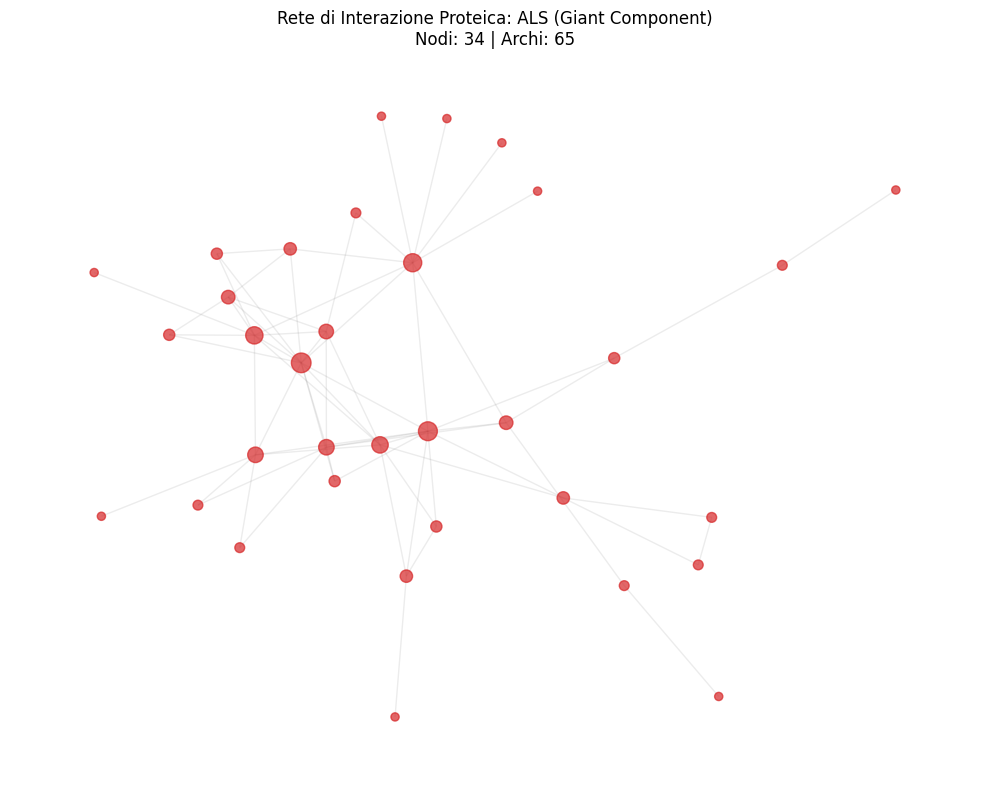

=== STATISTICHE GRAFO: MSA (Senza nodi isolati) ===
• Nodi isolati rimossi:   65
• Nodi totali (connessi): 43
• Archi totali:           42
• Densità:               0.046512
• Componenti connesse:    8
• Grado medio:            1.9535



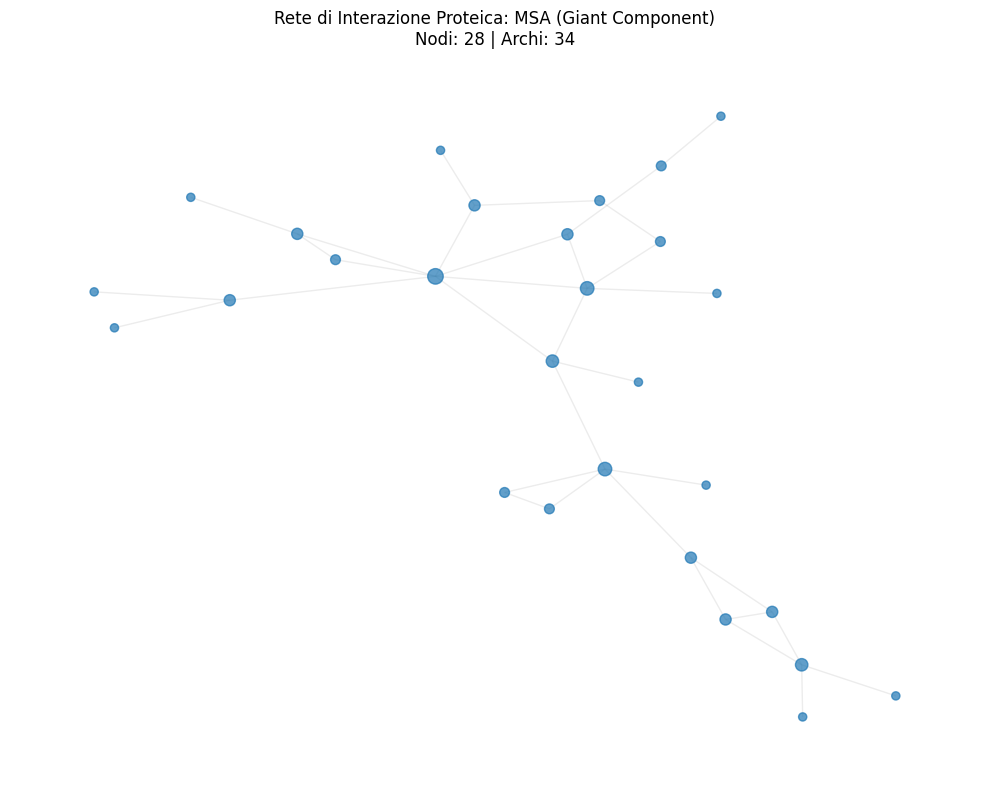

In [5]:
als_nodes_ds = pd.read_csv(als_path, sep='\t')
msa_nodes_ds = pd.read_csv(msa_path, sep='\t')

als_nodes_path = './sources/test_db/STRING_ALS.tsv'
msa_nodes_path = './sources/test_db/STRING_MSA.tsv'

als_edges_ds = pd.read_csv(als_nodes_path, sep='\t')
msa_edges_ds = pd.read_csv(msa_nodes_path, sep='\t')

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Funzione di pulizia per le stringhe dei nodi/ID
# ---------------------------------------------------------
def clean_string_id(val):
    if pd.isna(val):
        return None
    s = str(val).strip()
    if s.endswith(';'):
        s = s[:-1]
    return s.strip()

# ---------------------------------------------------------
# 2. Funzione per costruire, analizzare e visualizzare il grafo
# ---------------------------------------------------------
def build_analyze_and_plot_graph(name, nodes_df, edges_df, node_color='#1f77b4'):
    # Estrazione e pulizia nodi dal dataframe
    nodes_clean = set(nodes_df['STRING'].dropna().apply(clean_string_id))
    
    # Pulizia ID sorgente e destinazione per gli archi
    edge_node1 = edges_df['node1_string_id'].apply(clean_string_id)
    edge_node2 = edges_df['node2_string_id'].apply(clean_string_id)
    
    edges_clean = pd.DataFrame({'node1': edge_node1, 'node2': edge_node2}).dropna()
    
    # Costruzione del grafo NetworkX
    G = nx.Graph()
    G.add_nodes_from(nodes_clean)
    G.add_edges_from(zip(edges_clean['node1'], edges_clean['node2']))
    
    # ---------------------------------------------------------
    # PREPROCESSING: Rimozione dei nodi isolati (degree == 0)
    # ---------------------------------------------------------
    isolated_nodes = list(nx.isolates(G))
    G.remove_nodes_from(isolated_nodes)
    
    # Calcolo delle metriche sul grafo filtrato
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    density = nx.density(G)
    num_components = nx.number_connected_components(G)
    
    # Grado medio (2 * archi / nodi)
    avg_degree = (2 * num_edges / num_nodes) if num_nodes > 0 else 0.0
    
    # Stampa dei risultati
    print(f"=== STATISTICHE GRAFO: {name} (Senza nodi isolati) ===")
    print(f"• Nodi isolati rimossi:   {len(isolated_nodes)}")
    print(f"• Nodi totali (connessi): {num_nodes}")
    print(f"• Archi totali:           {num_edges}")
    print(f"• Densità:               {density:.6f}")
    print(f"• Componenti connesse:    {num_components}")
    print(f"• Grado medio:            {avg_degree:.4f}\n")
    
    # ---------------------------------------------------------
    # VISUALIZZAZIONE GRAFICA
    # ---------------------------------------------------------
    if num_nodes > 0:
        plt.figure(figsize=(10, 8))
        
        # Estraiamo la componente connessa principale (Giant Component) per un rendering più pulito
        largest_cc_nodes = max(nx.connected_components(G), key=len)
        G_giant = G.subgraph(largest_cc_nodes)
        
        # Layout posizionale a molla (Fruchterman-Reingold)
        pos = nx.spring_layout(G_giant, seed=42, k=0.15)
        
        # Calcolo dimensione nodi proporzionale al grado
        degrees = dict(G_giant.degree())
        node_sizes = [v * 15 + 20 for v in degrees.values()]
        
        # Disegno archi e nodi
        nx.draw_networkx_edges(G_giant, pos, alpha=0.15, edge_color='gray')
        nx.draw_networkx_nodes(G_giant, pos, node_size=node_sizes, node_color=node_color, alpha=0.7)
        
        plt.title(f"Rete di Interazione Proteica: {name} (Giant Component)\nNodi: {G_giant.number_of_nodes()} | Archi: {G_giant.number_of_edges()}", fontsize=12)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Nessun nodo da visualizzare per {name}.\n")
    
    return G

# ---------------------------------------------------------
# 3. Esecuzione separata per ALS e MSA
# ---------------------------------------------------------
G_als = build_analyze_and_plot_graph("ALS", als_nodes_ds, als_edges_ds, node_color='#d62728') # Rosso per ALS
G_msa = build_analyze_and_plot_graph("MSA", msa_nodes_ds, msa_edges_ds, node_color='#1f77b4') # Blu per MSA


=== STATISTICHE GRAFO: AD (Senza nodi isolati) ===
• Nodi isolati rimossi:   127
• Nodi totali (connessi): 104
• Archi totali:           160
• Densità:               0.029873
• Componenti connesse:    12
• Grado medio:            3.0769



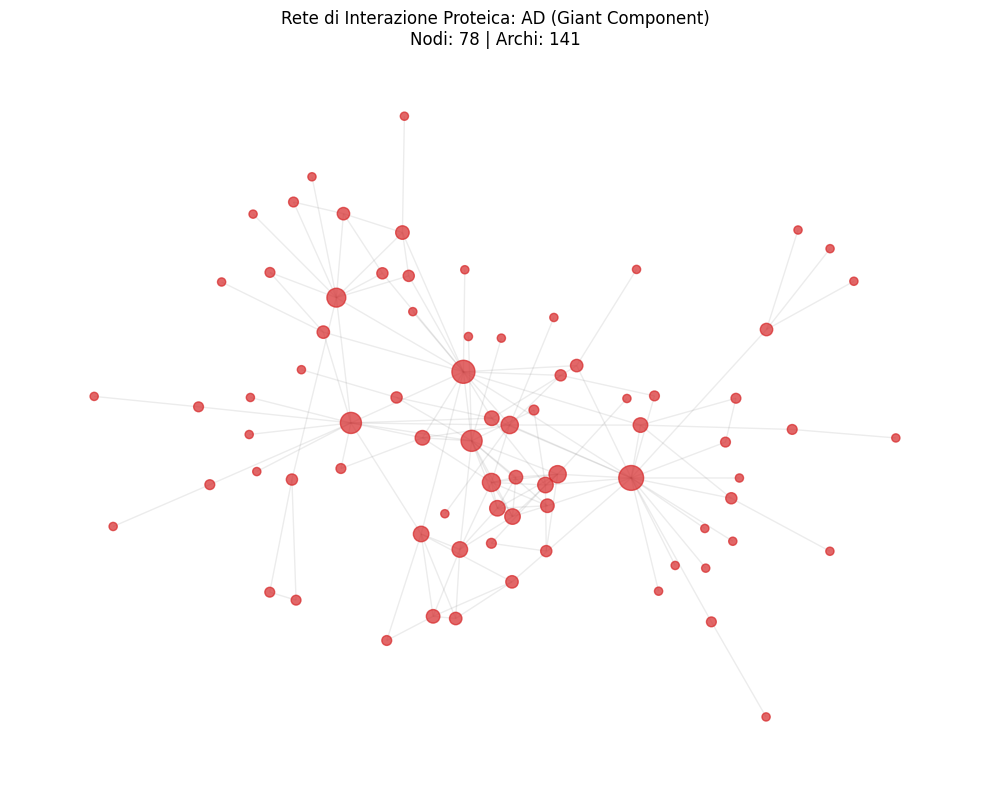

=== STATISTICHE GRAFO: PD (Senza nodi isolati) ===
• Nodi isolati rimossi:   86
• Nodi totali (connessi): 87
• Archi totali:           520
• Densità:               0.139000
• Componenti connesse:    2
• Grado medio:            11.9540



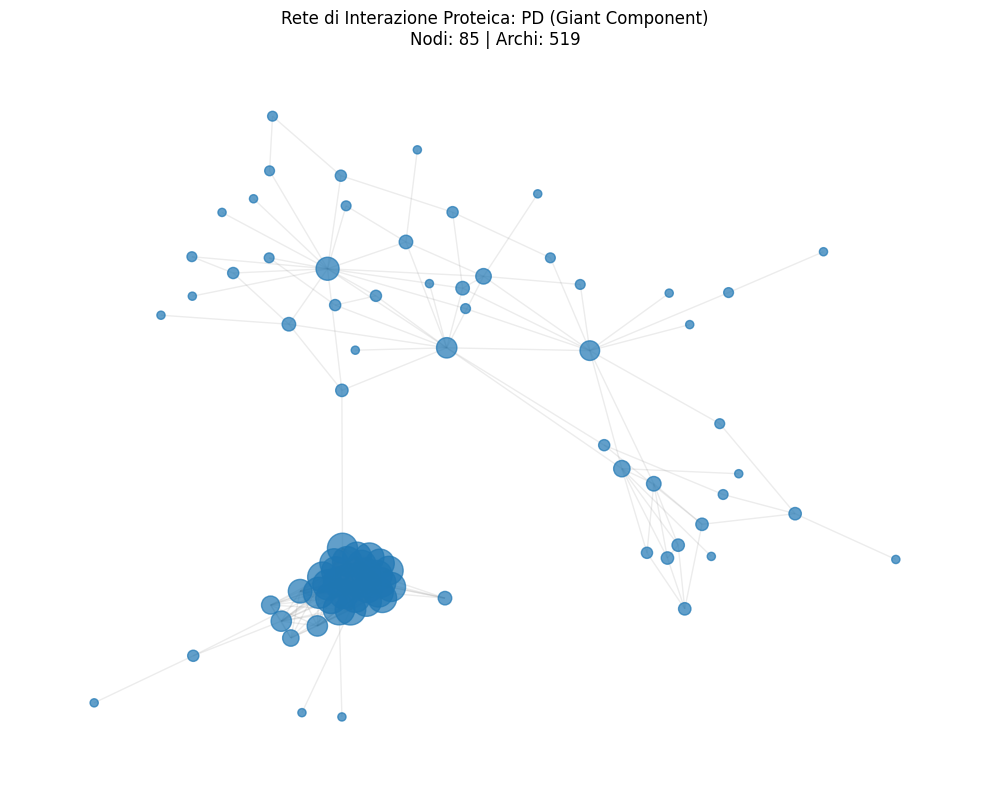

In [7]:
ad_nodes_ds = pd.read_csv(ad_path, sep='\t')
pd_nodes_ds = pd.read_csv(pd_path, sep='\t')

ad_nodes_path = './sources/STRING_AD_physical.tsv'
pd_nodes_path = './sources/STRING_PD_physical.tsv'

ad_edges_ds = pd.read_csv(ad_nodes_path, sep='\t')
pd_edges_ds = pd.read_csv(pd_nodes_path, sep='\t')

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Funzione di pulizia per le stringhe dei nodi/ID
# ---------------------------------------------------------
def clean_string_id(val):
    if pd.isna(val):
        return None
    s = str(val).strip()
    if s.endswith(';'):
        s = s[:-1]
    return s.strip()

# ---------------------------------------------------------
# 2. Funzione per costruire, analizzare e visualizzare il grafo
# ---------------------------------------------------------
def build_analyze_and_plot_graph(name, nodes_df, edges_df, node_color='#1f77b4'):
    # Estrazione e pulizia nodi dal dataframe
    nodes_clean = set(nodes_df['STRING'].dropna().apply(clean_string_id))
    
    # Pulizia ID sorgente e destinazione per gli archi
    edge_node1 = edges_df['node1_string_id'].apply(clean_string_id)
    edge_node2 = edges_df['node2_string_id'].apply(clean_string_id)
    
    edges_clean = pd.DataFrame({'node1': edge_node1, 'node2': edge_node2}).dropna()
    
    # Costruzione del grafo NetworkX
    G = nx.Graph()
    G.add_nodes_from(nodes_clean)
    G.add_edges_from(zip(edges_clean['node1'], edges_clean['node2']))
    
    # ---------------------------------------------------------
    # PREPROCESSING: Rimozione dei nodi isolati (degree == 0)
    # ---------------------------------------------------------
    isolated_nodes = list(nx.isolates(G))
    G.remove_nodes_from(isolated_nodes)
    
    # Calcolo delle metriche sul grafo filtrato
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    density = nx.density(G)
    num_components = nx.number_connected_components(G)
    
    # Grado medio (2 * archi / nodi)
    avg_degree = (2 * num_edges / num_nodes) if num_nodes > 0 else 0.0
    
    # Stampa dei risultati
    print(f"=== STATISTICHE GRAFO: {name} (Senza nodi isolati) ===")
    print(f"• Nodi isolati rimossi:   {len(isolated_nodes)}")
    print(f"• Nodi totali (connessi): {num_nodes}")
    print(f"• Archi totali:           {num_edges}")
    print(f"• Densità:               {density:.6f}")
    print(f"• Componenti connesse:    {num_components}")
    print(f"• Grado medio:            {avg_degree:.4f}\n")
    
    # ---------------------------------------------------------
    # VISUALIZZAZIONE GRAFICA
    # ---------------------------------------------------------
    if num_nodes > 0:
        plt.figure(figsize=(10, 8))
        
        # Estraiamo la componente connessa principale (Giant Component) per un rendering più pulito
        largest_cc_nodes = max(nx.connected_components(G), key=len)
        G_giant = G.subgraph(largest_cc_nodes)
        
        # Layout posizionale a molla (Fruchterman-Reingold)
        pos = nx.spring_layout(G_giant, seed=42, k=0.15)
        
        # Calcolo dimensione nodi proporzionale al grado
        degrees = dict(G_giant.degree())
        node_sizes = [v * 15 + 20 for v in degrees.values()]
        
        # Disegno archi e nodi
        nx.draw_networkx_edges(G_giant, pos, alpha=0.15, edge_color='gray')
        nx.draw_networkx_nodes(G_giant, pos, node_size=node_sizes, node_color=node_color, alpha=0.7)
        
        plt.title(f"Rete di Interazione Proteica: {name} (Giant Component)\nNodi: {G_giant.number_of_nodes()} | Archi: {G_giant.number_of_edges()}", fontsize=12)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Nessun nodo da visualizzare per {name}.\n")
    
    return G

# ---------------------------------------------------------
# 3. Esecuzione separata per AD e PD
# ---------------------------------------------------------
G_ad = build_analyze_and_plot_graph("AD", ad_nodes_ds, ad_edges_ds, node_color='#d62728') # Rosso per AD
G_pd = build_analyze_and_plot_graph("PD", pd_nodes_ds, pd_edges_ds, node_color='#1f77b4') # Blu per PD

In [10]:
from typing import List, Tuple
import torch
from torch_geometric.data import Data
from torch_geometric.utils import homophily
import networkx as nx
import numpy as np
from graph_data_manipulation import  rewire_non_degree_preserving_stratified_complete


# =========================================================
# 1. FUNZIONI DI HELPER PER IL REWIRING E TRASFORMAZIONE
# =========================================================

def _edge_index_to_half_undirected(edge_index: torch.Tensor) -> torch.Tensor:
    """Mantiene solo un arco per coppia non orientata (u < v)."""
    row, col = edge_index
    mask = row < col
    return torch.stack([row[mask], col[mask]], dim=0)

def _sample_simple_undirected_edges_on_nodes(
    nodes: List[int], num_edges: int, rng: np.random.Generator
) -> List[Tuple[int, int]]:
    """Campiona num_edges archi casuali semplici (u < v) tra i nodi dati."""
    n = len(nodes)
    max_edges = n * (n - 1) // 2
    assert num_edges <= max_edges, f"Impossibile campionare {num_edges} archi da {n} nodi"

    sampled_edges = set()
    while len(sampled_edges) < num_edges:
        u_idx, v_idx = rng.choice(n, size=2, replace=False)
        u, v = nodes[u_idx], nodes[v_idx]
        if u > v:
            u, v = v, u
        sampled_edges.add((u, v))
    
    return list(sampled_edges)

def convert_nx_graphs_to_pyg_data(G_ad: nx.Graph, G_pd: nx.Graph) -> Data:
    """
    Unisce G_ad e G_pd in un unico grafo PyG PyTorch Geometric.
    Label nodi:
      0 = AD-only
      1 = PD-only
      2 = Comuni ad entrambi (Shared)
    """
    nodes_ad = set(G_ad.nodes())
    nodes_pd = set(G_pd.nodes())

    all_nodes = sorted(list(nodes_ad.union(nodes_pd)))
    node_to_idx = {node: i for i, node in enumerate(all_nodes)}

    # Assegnazione label
    y_list = []
    for node in all_nodes:
        if node in nodes_ad and node in nodes_pd:
            y_list.append(2)  # Comuni
        elif node in nodes_ad:
            y_list.append(0)  # AD-only
        else:
            y_list.append(1)  # PD-only

    # Estrazione archi unici (half format: u < v)
    edges = set()
    for G in [G_ad, G_pd]:
        for u, v in G.edges():
            u_idx, v_idx = node_to_idx[u], node_to_idx[v]
            if u_idx > v_idx:
                u_idx, v_idx = v_idx, u_idx
            edges.add((u_idx, v_idx))

    edges_arr = np.array(list(edges), dtype=np.int64).T if edges else np.empty((2, 0), dtype=np.int64)
    edge_index = torch.tensor(edges_arr, dtype=torch.long)
    y = torch.tensor(y_list, dtype=torch.long)

    # Inizializza data.x come feature dummy per compatibilità PyG
    x = torch.ones((len(all_nodes), 1), dtype=torch.float32)

    return Data(x=x, edge_index=edge_index, y=y)


# =========================================================
# 3. CONVERSIONE, REWIRING E MISURA DELL'OMOFILIA
# =========================================================

# A. Converti i grafi NetworkX precedenti (G_ad e G_pd) in PyG Data
data_orig = convert_nx_graphs_to_pyg_data(G_ad, G_pd)

# B. Applica la funzione di Rewiring
data_rewired = rewire_non_degree_preserving_stratified_complete(data_orig, seed=42)

# C. Calcolo dell'Omofilia
# PyG accetta grafi sia orientati che non; rendiamo l'edge_index simmetrico per il calcolo corretto
def get_symmetric_edge_index(ei: torch.Tensor) -> torch.Tensor:
    rev = torch.stack([ei[1], ei[0]], dim=0)
    return torch.cat([ei, rev], dim=1)

ei_orig_sym = get_symmetric_edge_index(data_orig.edge_index)
ei_rewired_sym = get_symmetric_edge_index(data_rewired.edge_index)

# Calcolo delle metriche di omofilia (Edge Homophily & Node Homophily)
edge_homo_orig = homophily(ei_orig_sym, data_orig.y, method='edge')
node_homo_orig = homophily(ei_orig_sym, data_orig.y, method='node')

edge_homo_rewired = homophily(ei_rewired_sym, data_rewired.y, method='edge')
node_homo_rewired = homophily(ei_rewired_sym, data_rewired.y, method='node')

# D. Stampa dei Risultati
print("=========================================================")
print("=== RISULTATI CONFRONTO OMOFILIA (PRIMA vs DOPO REWIRING) ===")
print("=========================================================")
print(f"• Omofilia d'Arco (Edge Homophily)    ORIGINALE: {edge_homo_orig:.4f}")
print(f"• Omofilia d'Arco (Edge Homophily)    REWIRED:   {edge_homo_rewired:.4f}")
print("---------------------------------------------------------")
print(f"• Omofilia di Nodo (Node Homophily)   ORIGINALE: {node_homo_orig:.4f}")
print(f"• Omofilia di Nodo (Node Homophily)   REWIRED:   {node_homo_rewired:.4f}")
print("=========================================================")

=== RISULTATI CONFRONTO OMOFILIA (PRIMA vs DOPO REWIRING) ===
• Omofilia d'Arco (Edge Homophily)    ORIGINALE: 0.8348
• Omofilia d'Arco (Edge Homophily)    REWIRED:   0.8348
---------------------------------------------------------
• Omofilia di Nodo (Node Homophily)   ORIGINALE: 0.7723
• Omofilia di Nodo (Node Homophily)   REWIRED:   0.8030
